In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



#load data set
model = pd.read_csv("dataset_final.csv")

In [23]:
#EDA expolaroty data analysis
model.info() #meliat apakah data ada yang missing atau tidak, melihat barapa jumla data nya dan meliat tipe data nya
model.describe() #melihat statistik data, seperti mean, median, modus, standar deviasi, min, max, dan 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   usia                            2000 non-null   int64  
 1   jenis_kelamin                   2000 non-null   object 
 2   bmi                             2000 non-null   float64
 3   status_merokok                  2000 non-null   object 
 4   tingkat_aktivitas_fisik         2000 non-null   object 
 5   jam_tidur_per_malam             2000 non-null   int64  
 6   tingkat_stres                   2000 non-null   object 
 7   frekuensi_makan_pedas           2000 non-null   object 
 8   frekuensi_makan_berlemak        2000 non-null   object 
 9   konsumsi_kopi_per_hari          2000 non-null   int64  
 10  konsumsi_alkohol                2000 non-null   object 
 11  minuman_bersoda_per_minggu      2000 non-null   int64  
 12  frekuensi_fast_food_per_minggu  20

,usia,bmi,jam_tidur_per_malam,konsumsi_kopi_per_hari,minuman_bersoda_per_minggu,frekuensi_fast_food_per_minggu,risiko_gerd
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000
mean,41.675000,26.570050,6.590000,2.474500,7.091000,3.589500,0.5050
std,13.666666,4.889564,1.691251,1.701704,4.357317,2.277407,0.5001
min,18.000000,18.000000,4.000000,0.000000,0.000000,0.000000,0.0000
25%,30.000000,22.300000,5.000000,1.000000,3.000000,2.000000,0.0000
50%,42.000000,26.700000,7.000000,2.000000,7.000000,4.000000,1.0000
75%,53.000000,30.900000,8.000000,4.000000,11.000000,6.000000,1.0000
max,65.000000,35.000000,9.000000,5.000000,14.000000,7.000000,1.0000


In [24]:
model.head() #melihat 5 data teratas

,usia,jenis_kelamin,bmi,status_merokok,tingkat_aktivitas_fisik,jam_tidur_per_malam,tingkat_stres,frekuensi_makan_pedas,frekuensi_makan_berlemak,konsumsi_kopi_per_hari,konsumsi_alkohol,minuman_bersoda_per_minggu,frekuensi_fast_food_per_minggu,makan_larut_malam,risiko_gerd
0,56,Laki-laki,34.9,Tidak Merokok,Rendah,6,Sedang,Kadang,Kadang,1,Mingguan,5,1,Tidak,0
1,46,Laki-laki,31.9,Perokok Aktif,Rendah,4,Tinggi,Kadang,Kadang,5,Sesekali,14,5,Ya,1
2,32,Perempuan,29.8,Perokok Aktif,Tinggi,4,Sedang,Jarang,Sering,1,Mingguan,7,2,Ya,1
3,60,Perempuan,27.1,Perokok Aktif,Tinggi,4,Tinggi,Jarang,Jarang,2,Tidak Pernah,12,6,Tidak,1
4,25,Laki-laki,25.6,Tidak Merokok,Sedang,7,Tinggi,Kadang,Sering,0,Tidak Pernah,6,1,Ya,1


In [25]:
model.isnull().sum() #melihat apakah ada data yang missing atau tidak, jika ada akan muncul jumlah data yang missing untuk setiap kolomnya

usia                              0
jenis_kelamin                     0
bmi                               0
status_merokok                    0
tingkat_aktivitas_fisik           0
jam_tidur_per_malam               0
tingkat_stres                     0
frekuensi_makan_pedas             0
frekuensi_makan_berlemak          0
konsumsi_kopi_per_hari            0
konsumsi_alkohol                  0
minuman_bersoda_per_minggu        0
frekuensi_fast_food_per_minggu    0
makan_larut_malam                 0
risiko_gerd                       0
dtype: int64

In [26]:
model_final = model.drop(['usia'], axis=1) #menghapus kolom usia karena tidak terlalu berpengaruh terhadap hasil prediksi   
model_final.head() #melihat 5 data teratas setelah kolom usia dihapus

,jenis_kelamin,bmi,status_merokok,tingkat_aktivitas_fisik,jam_tidur_per_malam,tingkat_stres,frekuensi_makan_pedas,frekuensi_makan_berlemak,konsumsi_kopi_per_hari,konsumsi_alkohol,minuman_bersoda_per_minggu,frekuensi_fast_food_per_minggu,makan_larut_malam,risiko_gerd
0,Laki-laki,34.9,Tidak Merokok,Rendah,6,Sedang,Kadang,Kadang,1,Mingguan,5,1,Tidak,0
1,Laki-laki,31.9,Perokok Aktif,Rendah,4,Tinggi,Kadang,Kadang,5,Sesekali,14,5,Ya,1
2,Perempuan,29.8,Perokok Aktif,Tinggi,4,Sedang,Jarang,Sering,1,Mingguan,7,2,Ya,1
3,Perempuan,27.1,Perokok Aktif,Tinggi,4,Tinggi,Jarang,Jarang,2,Tidak Pernah,12,6,Tidak,1
4,Laki-laki,25.6,Tidak Merokok,Sedang,7,Tinggi,Kadang,Sering,0,Tidak Pernah,6,1,Ya,1


In [36]:
model_final.describe(include='object') #melihat statistik data untuk data kategorikal, seperti jumlah kategori, frekuensi, dan nilai unik

,jenis_kelamin,status_merokok,tingkat_aktivitas_fisik,tingkat_stres,frekuensi_makan_pedas,frekuensi_makan_berlemak,konsumsi_alkohol,makan_larut_malam
count,2000,2000,2000,2000,2000,2000,2000,2000
unique,2,3,3,3,5,5,4,2
top,Perempuan,Tidak Merokok,Sedang,Sedang,Kadang,Kadang,Tidak Pernah,Tidak
freq,1018,1131,802,822,607,613,846,1154


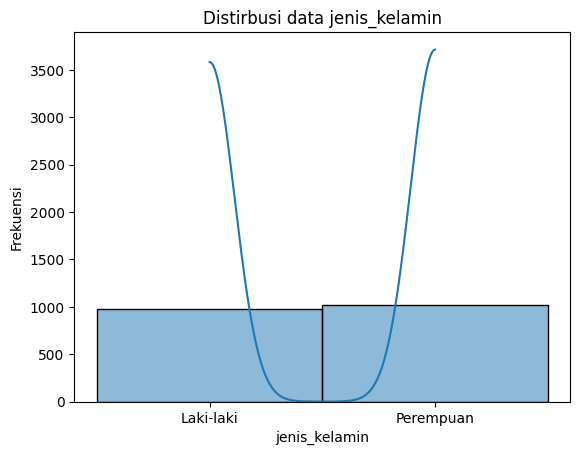

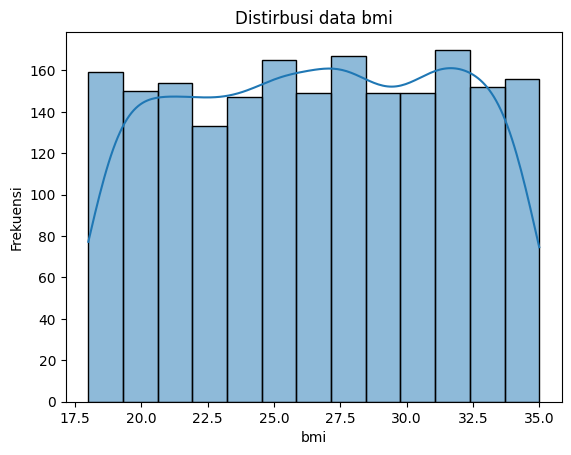

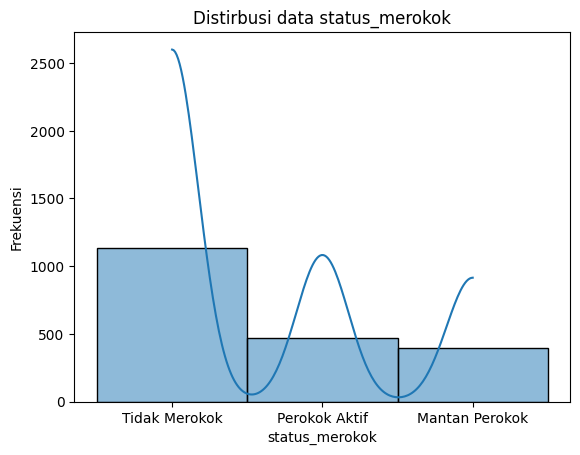

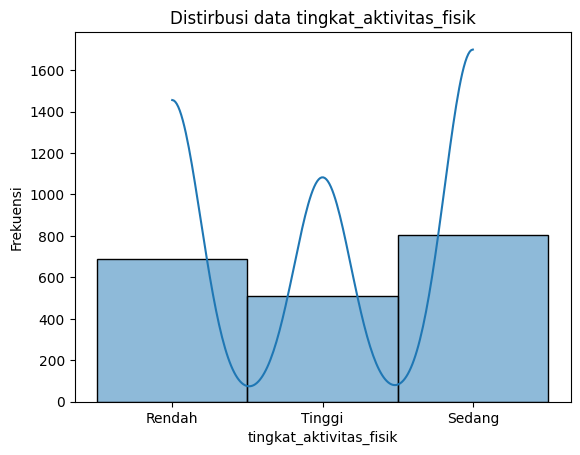

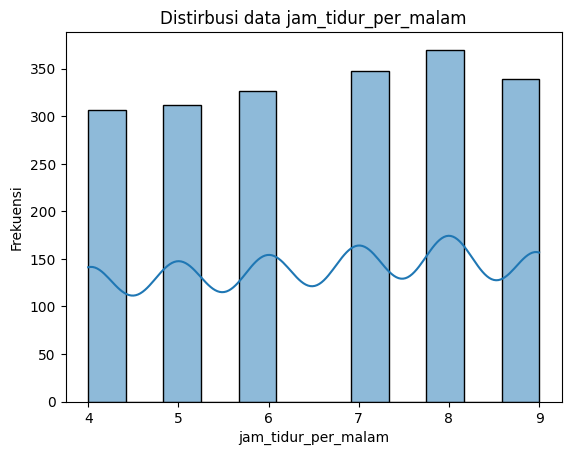

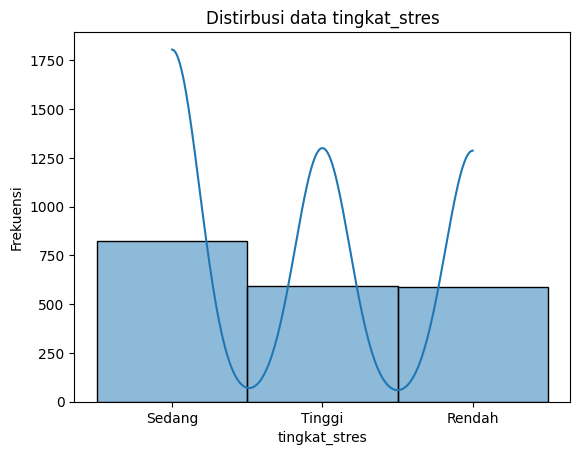

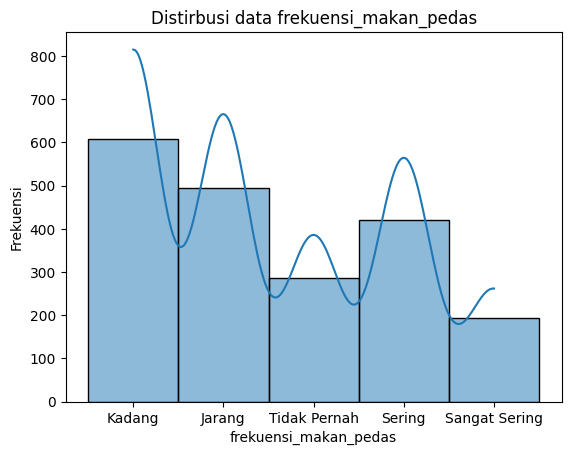

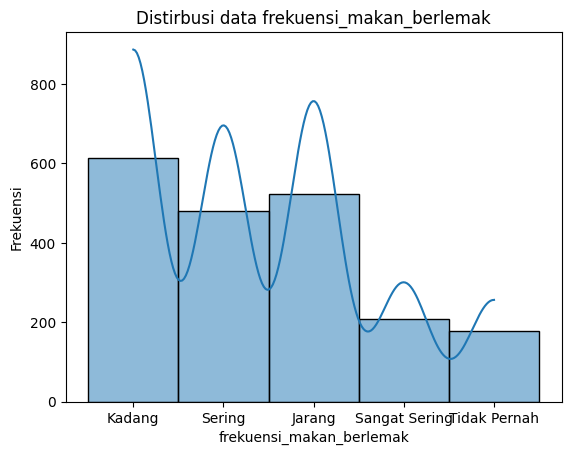

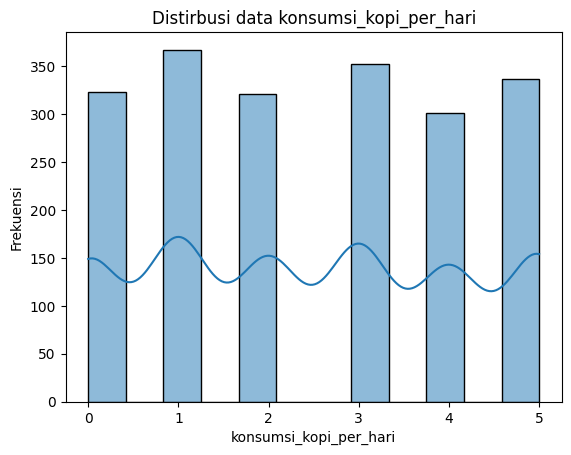

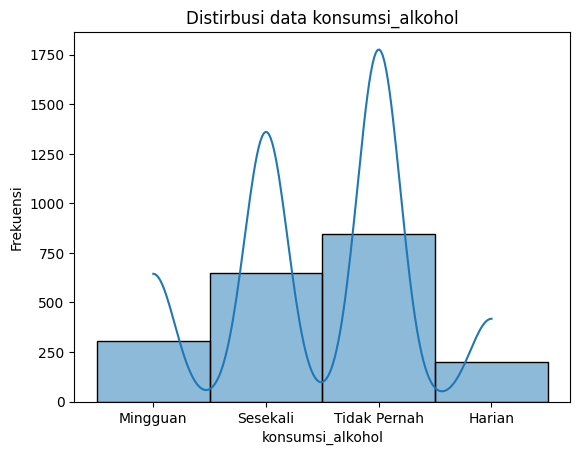

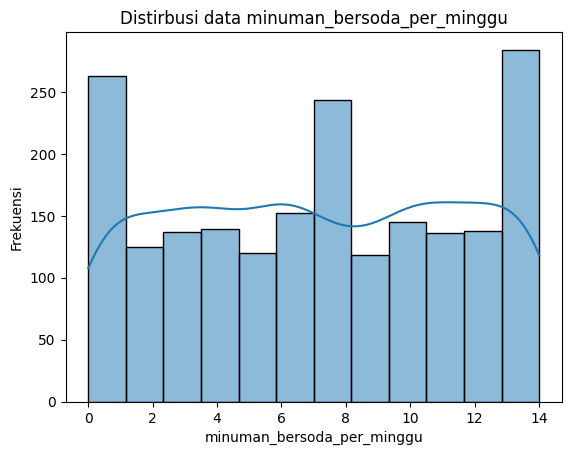

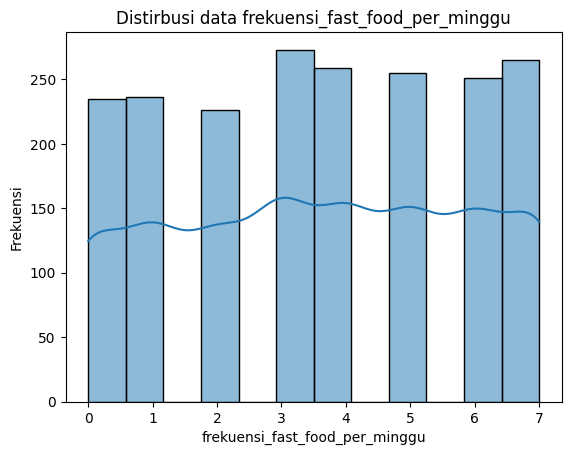

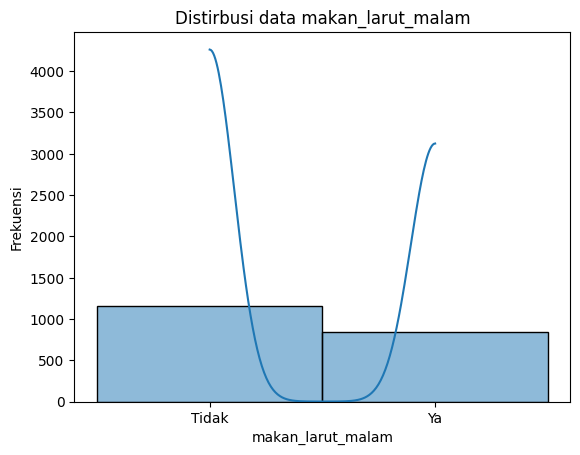

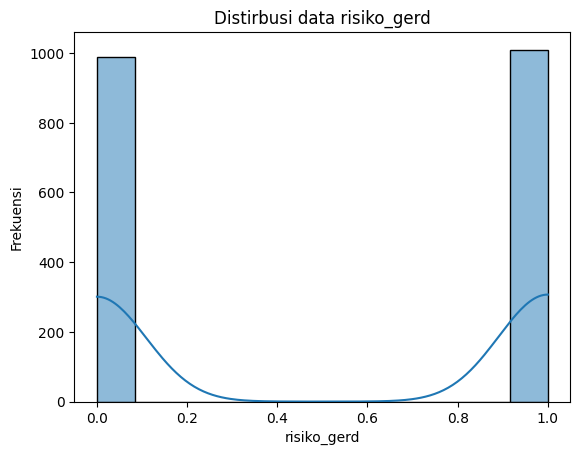

In [28]:
#melihat distibusi data mengunakan hhsitogram

for i in model_final.columns:
    
    plt.Figure(figsize=(50,5))
    sns.histplot(model_final[i], kde=True)
    
    plt.title(f"Distirbusi data {i}")
    plt.xlabel(i)
    plt.ylabel("Frekuensi")
    plt.show() 

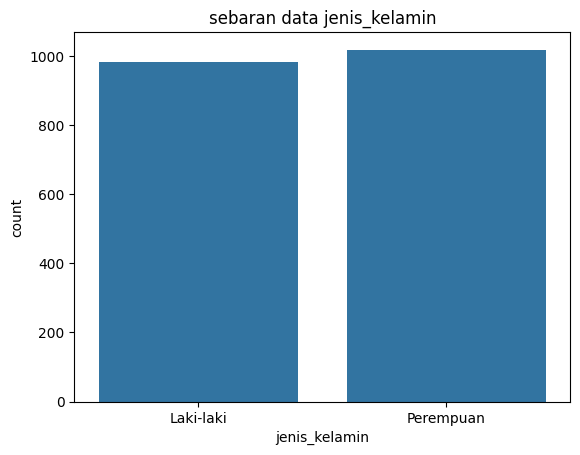

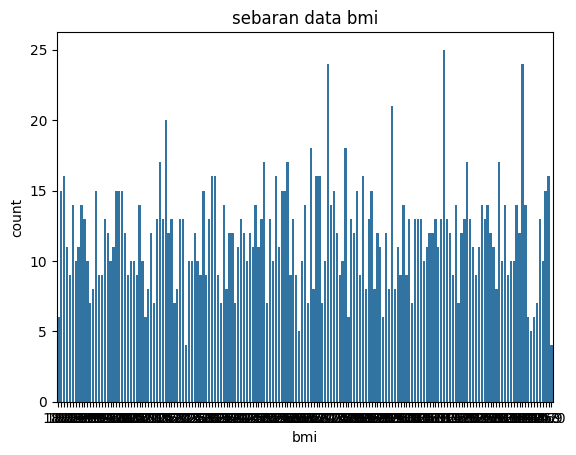

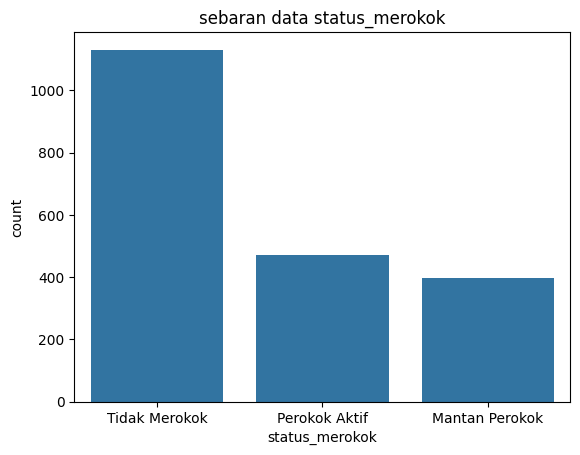

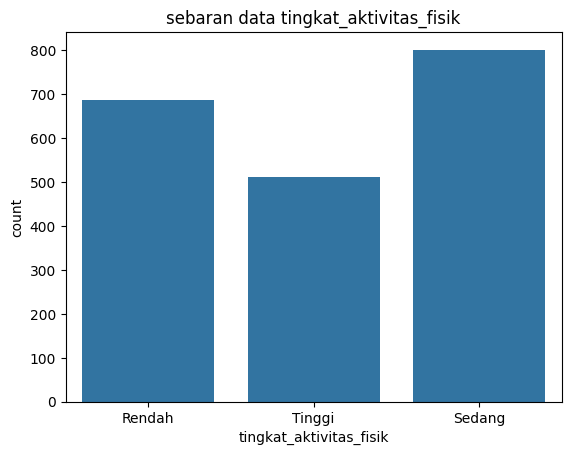

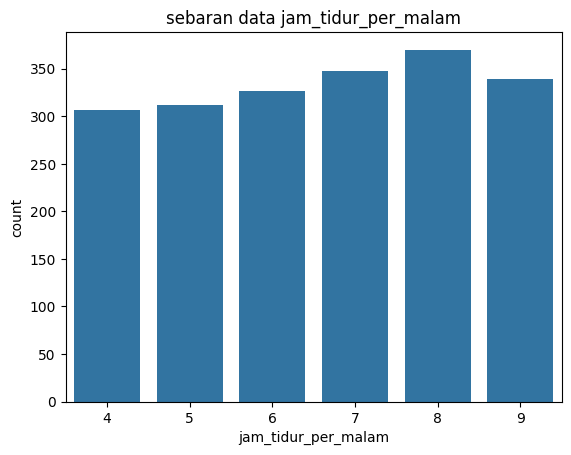

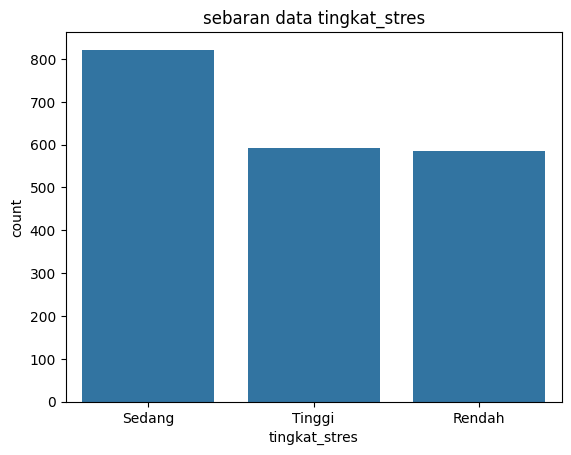

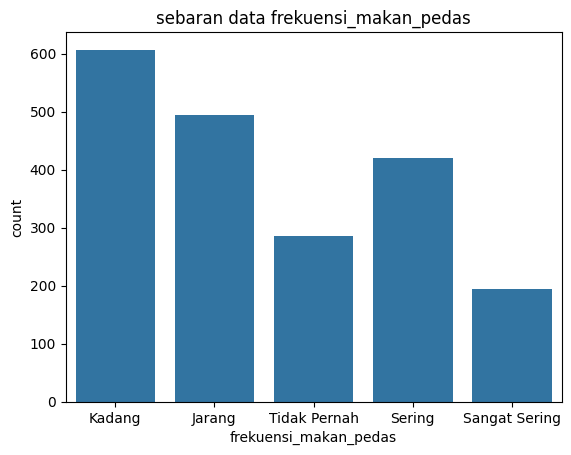

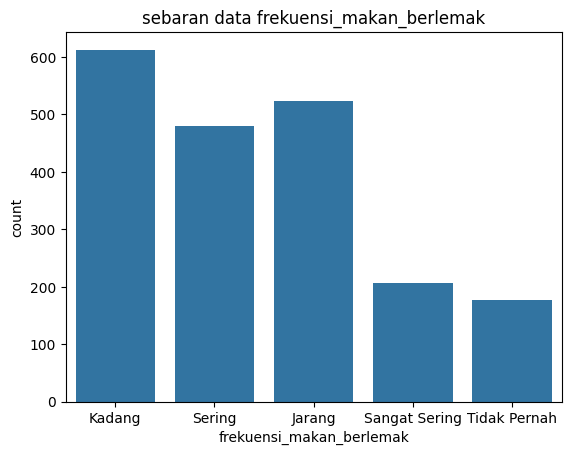

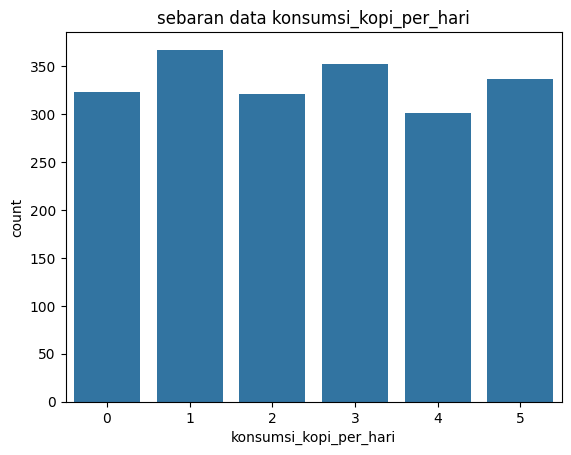

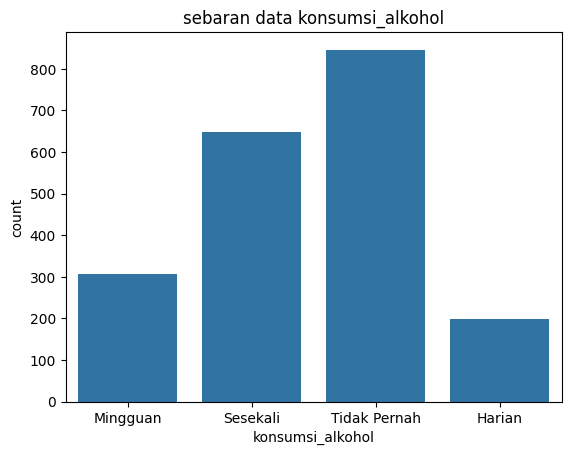

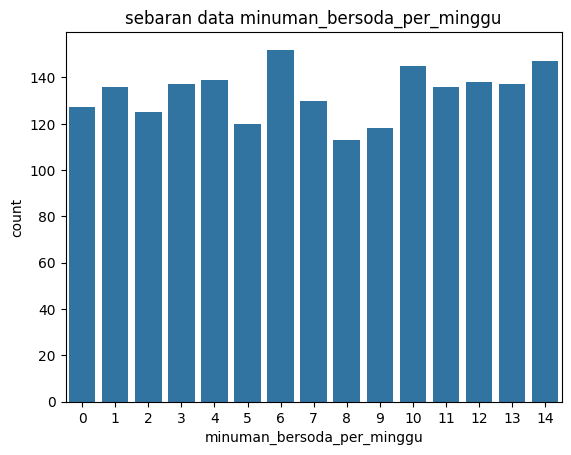

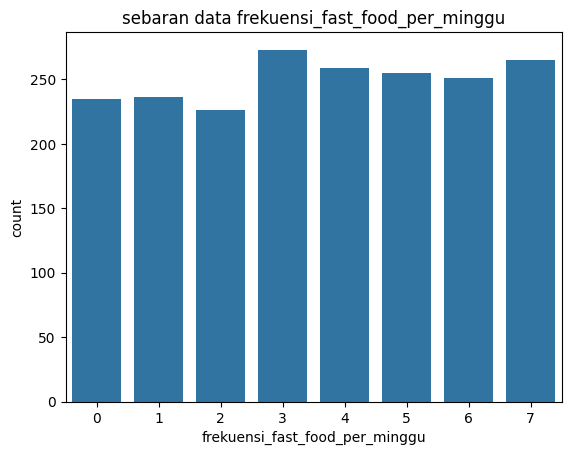

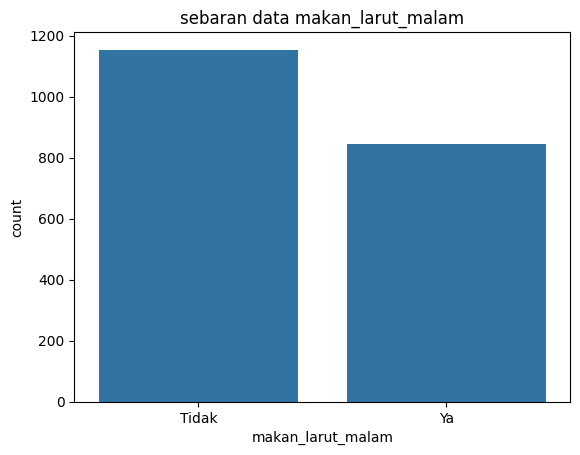

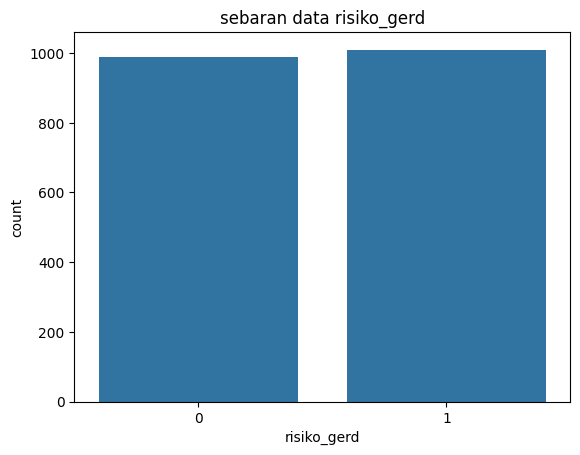

In [29]:
#melihat sebaran data menggunakan countplot

for i in model_final.columns:
    plt.Figure(figsize=(20,5))
    sns.countplot(x=model_final[i])
    plt.xlabel(i)
    plt.title(f"sebaran data {i}")
    plt.show()

In [30]:
#melihat data imbalence mengunakn if statement


for i in model_final.columns:
    
    jumlan = model_final[i].value_counts() #bagian ini untuk menghitung dsitribusi data disetiap class

    
    max_value = jumlan.max()
    min_value = jumlan.min()
    
    rasio = max_value / min_value
    
    if rasio < 1.5:
        print(f"data tidak imbalence pada kolom {i} dengan rasio{rasio:.2f}")
    elif rasio > 1.5 and rasio <= 3:
        print(f"data sedikit imbalence pada kolom {i} dengan rasio{rasio:.2f}")
    else:
        print(f"data imbalence pada kolom {i} dengan rasio{rasio:.2f}")


data tidak imbalence pada kolom jenis_kelamin dengan rasio1.04
data imbalence pada kolom bmi dengan rasio6.25
data sedikit imbalence pada kolom status_merokok dengan rasio2.84
data sedikit imbalence pada kolom tingkat_aktivitas_fisik dengan rasio1.57
data tidak imbalence pada kolom jam_tidur_per_malam dengan rasio1.21
data tidak imbalence pada kolom tingkat_stres dengan rasio1.40
data imbalence pada kolom frekuensi_makan_pedas dengan rasio3.13
data imbalence pada kolom frekuensi_makan_berlemak dengan rasio3.46
data tidak imbalence pada kolom konsumsi_kopi_per_hari dengan rasio1.22
data imbalence pada kolom konsumsi_alkohol dengan rasio4.25
data tidak imbalence pada kolom minuman_bersoda_per_minggu dengan rasio1.35
data tidak imbalence pada kolom frekuensi_fast_food_per_minggu dengan rasio1.21
data tidak imbalence pada kolom makan_larut_malam dengan rasio1.36
data tidak imbalence pada kolom risiko_gerd dengan rasio1.02


<Axes: xlabel='count', ylabel='frekuensi_makan_berlemak'>

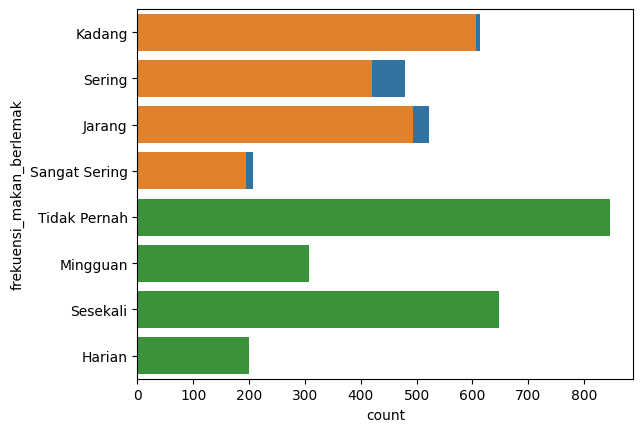

In [31]:
#PENGECEKAN DATA IMBALENCE UNTUK KATEGORIKAL
import seaborn as sns
model_final['frekuensi_makan_berlemak' ].value_counts()
model_final['frekuensi_makan_pedas' ].value_counts()
model_final['konsumsi_alkohol' ].value_counts()

sns.countplot(model_final['frekuensi_makan_berlemak'])
sns.countplot(model_final['frekuensi_makan_pedas'])
sns.countplot(model_final['konsumsi_alkohol'])



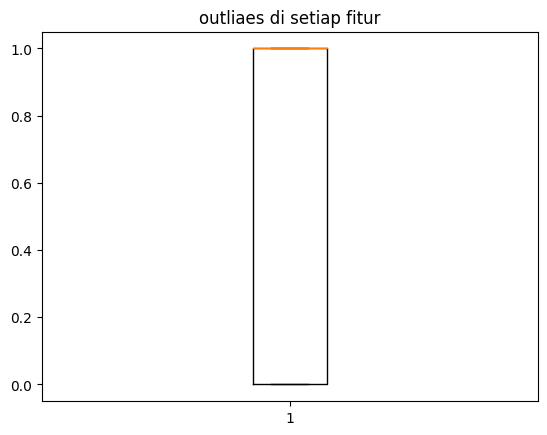

In [32]:
#detector and handling outliers
def outlier(model_final):
    Q1 = int(model_final["risiko_gerd"].quantile(0.25))
    Q3 = int(model_final["risiko_gerd"].quantile(0.75))
         
    IQR = Q3 - Q1
    lower_data = Q1 - 1.5 * IQR
    upper_data = Q3 + 1.5 * IQR
        
    outliers = model_final[(model_final["risiko_gerd"] < lower_data) | (model_final["risiko_gerd"] > upper_data)]
        
    return outliers
plt.boxplot(model_final["risiko_gerd"])
plt.title("outliaes di setiap fitur")
plt.show()

In [33]:
#spliting data

x = model_final.drop(columns=['risiko_gerd']) #DISINI KITA MEMISAHKAN ANTARA FITUR DAN TARGET
y = model_final['risiko_gerd'] #INI BAGIAN TARGETNYA

x_latih, x_uji, y_latih, y_uji = train_test_split(x, y , test_size=0.3, random_state=42)

In [34]:
#TEKNIK OVERSAMPLING UNTUK MENGATASI DATA IMBALENCE DENGAN UPSAMPLING


In [39]:
#feature encoding
def encoding():
    encode_model = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    x_latih_encode = encode_model.fit_transform(x_latih[[ 'bmi', 'jam_tidur_per_malam', 'konsumsi_kopi_per_hari', 'minuman_bersoda_per_minggu', 'frekuensi_fast_food_per_minggu']])
    x_uji_encode = encode_model.transform(x_uji[[ 'bmi', 'jam_tidur_per_malam', 'konsumsi_kopi_per_hari', 'minuman_bersoda_per_minggu', 'frekuensi_fast_food_per_minggu']])

    #membuat dataframe

    encode_df = pd.DataFrame(
        x_latih_encode, columns=encode_model.get_feature_names_out() #bagian ini untuk membuat nama kolom pada dataframe hasil encoding
    )

    return encode_df, encode_model, x_uji_encode
encoding_model = encoding()
print(encoding_model)

(      bmi_18.0  bmi_18.1  bmi_18.2  bmi_18.3  bmi_18.4  bmi_18.5  bmi_18.6  \
0          0.0       0.0       0.0       0.0       0.0       0.0       0.0   
1          0.0       0.0       0.0       0.0       0.0       0.0       0.0   
2          0.0       0.0       0.0       0.0       0.0       0.0       0.0   
3          0.0       0.0       0.0       0.0       0.0       0.0       0.0   
4          0.0       0.0       0.0       0.0       0.0       0.0       0.0   
...        ...       ...       ...       ...       ...       ...       ...   
1395       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
1396       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
1397       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
1398       0.0       0.0       0.0       0.0       0.0       0.0       0.0   
1399       0.0       0.0       0.0       0.0       0.0       0.0       0.0   

      bmi_18.7  bmi_18.8  bmi_18.9  ...  minuman_bersoda_per_m

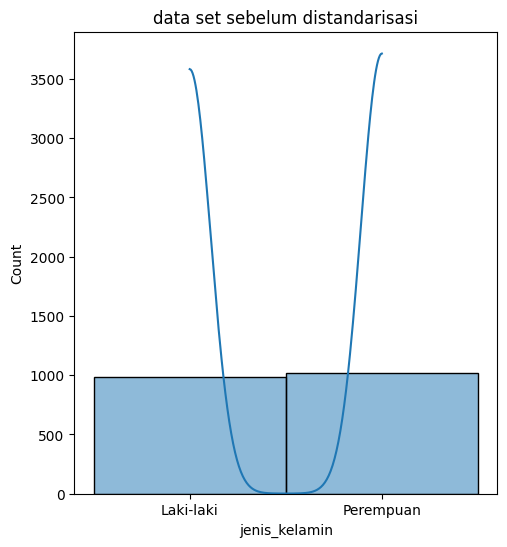

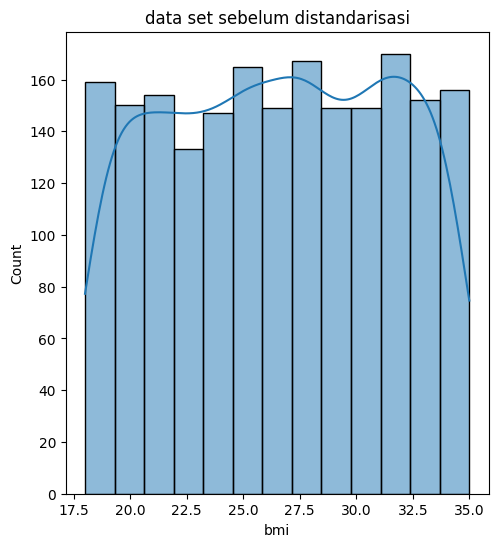

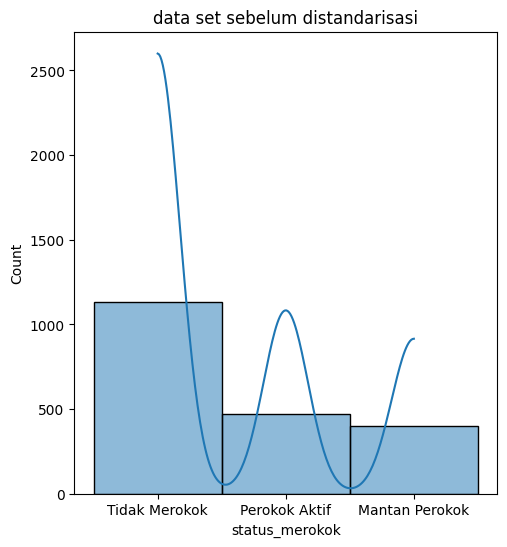

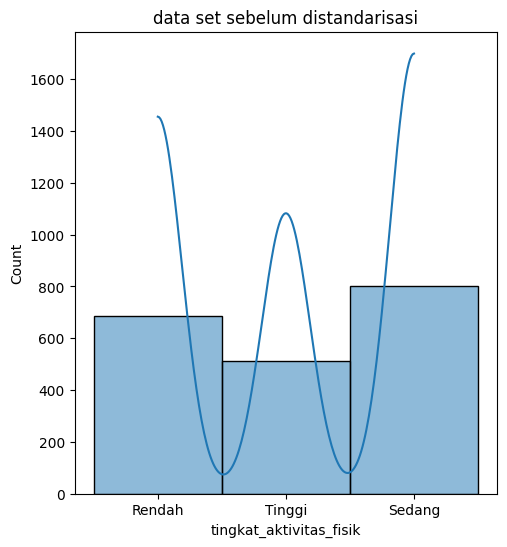

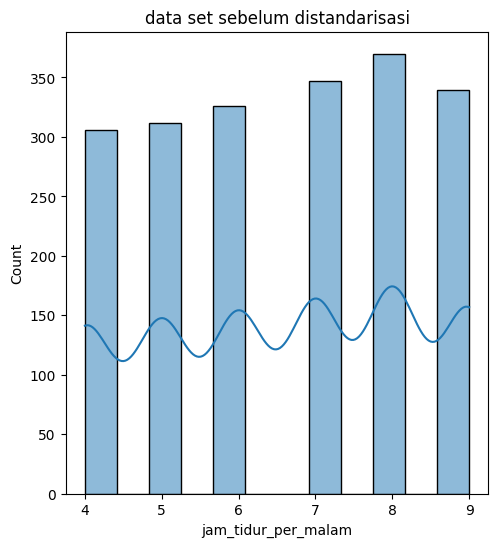

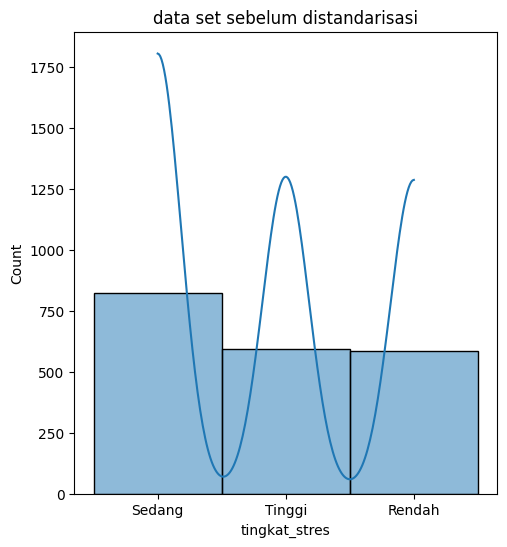

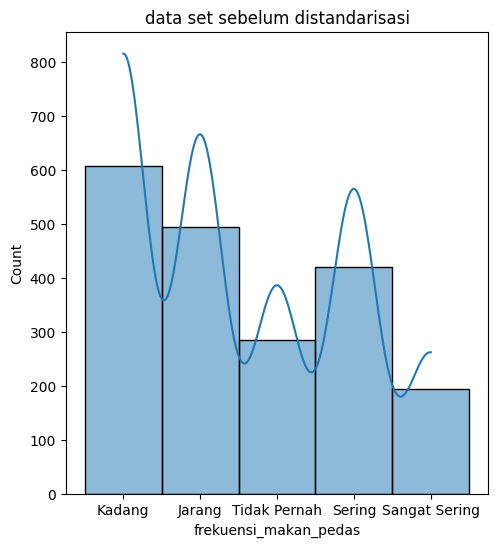

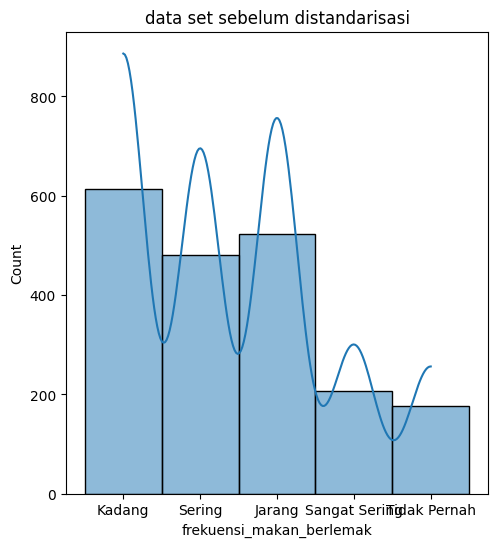

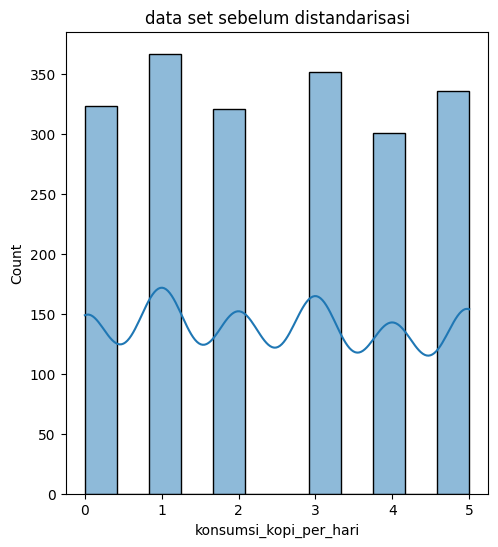

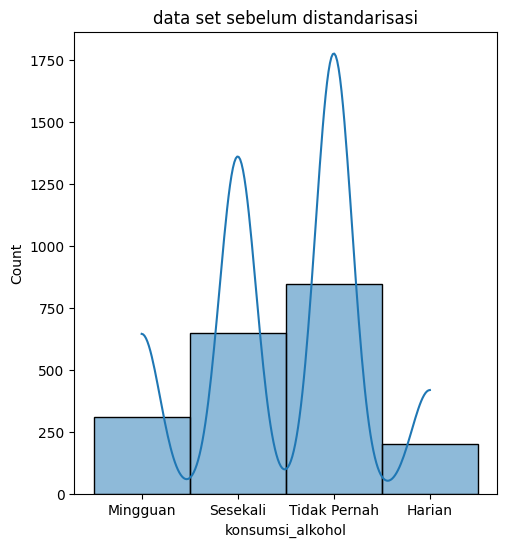

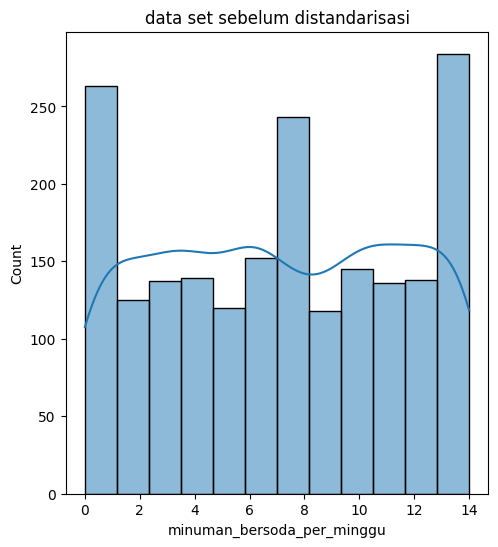

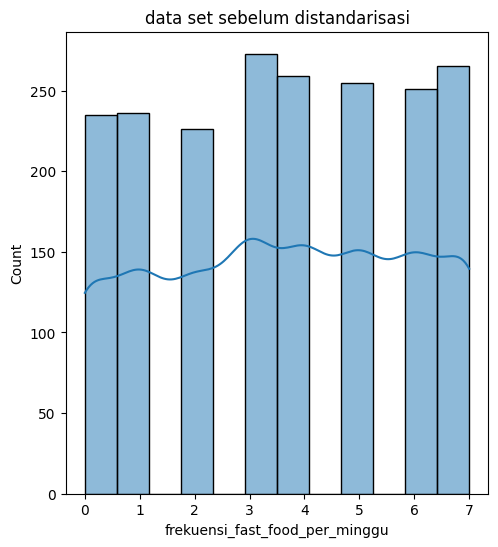

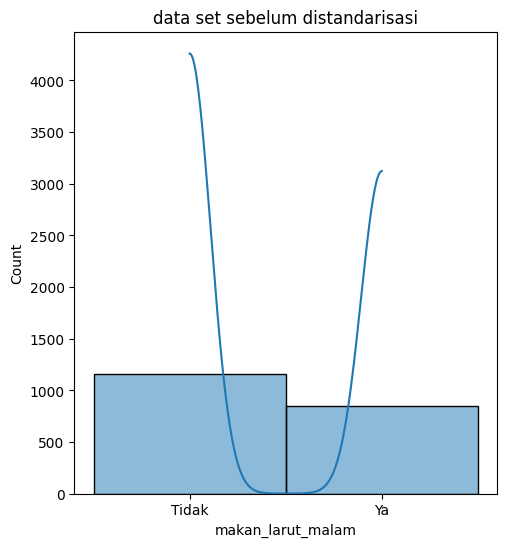

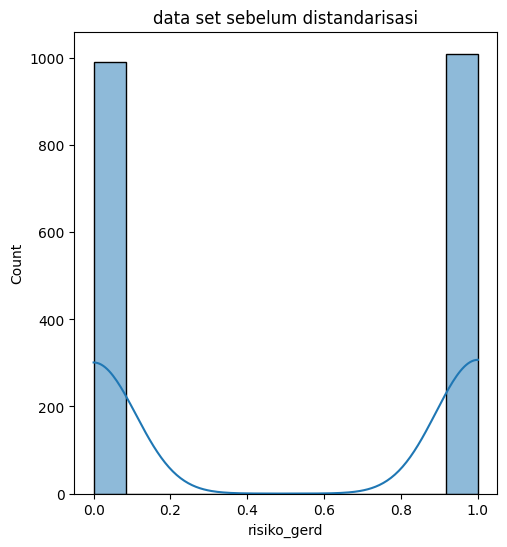

In [42]:
#standarisasi data 

#melihat data sebelum distandarisasi

for i in model_final.columns:
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(model_final[i], kde=True)
    plt.title("data set sebelum distandarisasi")
    plt.show()


In [46]:
#scaling data menggunakan standard scaler
scaler = StandardScaler()

x_latih_stdr = scaler.fit_transform(encoding()[0])
x_uji_stdr = scaler.transform(encoding()[2])

print(x_latih_stdr.dtype)
print(x_uji_stdr.dtype)


float64
float64


C:\Users\ASUS Vivobook\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
